# Лабораторная работа № 5

## Метод опорных векторов

Метод опорных векторов применяется для решения задач классификации и регрессии.  
В данной работе метод используется для бинарной классификации: определения подлинности банкнот по числовым признакам изображений.

В работе выполняются следующие задачи:

1. Анализ результатов классификации для набора данных Banknote Authentication.
2. Подбор наилучших параметров SVM с использованием кросс-валидации.
3. Проверка возможности улучшения качества классификации для набора Adult Income за счет изменения параметров SVM.

### Банкноты

In [2]:
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Загрузка набора данных Banknote Authentication

banknote_columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

banknote = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=banknote_columns
)

print("Размерность данных:", banknote.shape)
print("\nИнформация о признаках:")
print(banknote.info())

print("\nПервые строки набора данных:")
display(banknote.head())

print("\nРаспределение классов:")
display(banknote["class"].value_counts().sort_index())

print("\nДоля классов:")
display(banknote["class"].value_counts(normalize=True).sort_index())

Размерность данных: (1372, 5)

Информация о признаках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

Первые строки набора данных:


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Распределение классов:


class
0    762
1    610
Name: count, dtype: int64


Доля классов:


class
0    0.555394
1    0.444606
Name: proportion, dtype: float64

Вейвлет-преобразование – это способ “разобрать” изображение на детали разного масштаба: крупные элементы, мелкие элементы, резкие переходы и текстуры.
После такого преобразования можно посчитать числовые характеристики изображения:
| Характеристика | Что показывает                                             |
| -------------- | ---------------------------------------------------------- |
| Дисперсия      | насколько сильно отличаются значения признаков изображения |
| Асимметрия     | в какую сторону смещено распределение значений             |
| Эксцесс        | насколько выражены резкие пики и выбросы                   |
| Энтропия       | насколько изображение сложное или неоднородное             |

Набор данных содержит 1372 объекта и 4 числовых признака, полученных на основе характеристик изображений банкнот.  
Целевая переменная `class` показывает принадлежность объекта к одному из двух классов: настоящая или фальшивая банкнота.

Так как SVM чувствителен к масштабу признаков, перед обучением моделей далее используется стандартизация данных.


In [3]:
# Разделение по условию задания:
# последние 107 объектов класса 0 и последние 119 объектов класса 1 идут в test

class_0 = banknote[banknote["class"] == 0]
class_1 = banknote[banknote["class"] == 1]

test_0 = class_0.tail(107)
test_1 = class_1.tail(119)

train_0 = class_0.iloc[:-107]
train_1 = class_1.iloc[:-119]

train_banknote = pd.concat([train_0, train_1], axis=0).reset_index(drop=True)
test_banknote = pd.concat([test_0, test_1], axis=0).reset_index(drop=True)

X_train = train_banknote.drop(columns=["class"])
y_train = train_banknote["class"]

X_test = test_banknote.drop(columns=["class"])
y_test = test_banknote["class"]

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

print("\nРаспределение классов в train:")
display(y_train.value_counts().sort_index())

print("\nРаспределение классов в test:")
display(y_test.value_counts().sort_index())

Размер обучающей выборки: (1146, 4)
Размер тестовой выборки: (226, 4)

Распределение классов в train:


class
0    655
1    491
Name: count, dtype: int64


Распределение классов в test:


class
0    107
1    119
Name: count, dtype: int64

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Обучаем модель, делаем прогноз и выводим основные метрики качества.
    """
    t1 = time.time()
    t2 = time.perf_counter()
    t3 = time.process_time()
    
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    
    total_time = time.time() - t1
    performance_time = time.perf_counter() - t2
    processor_time = time.process_time() - t3
    
    accuracy = accuracy_score(y_test, prediction)
    
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print("Accuracy:", round(accuracy, 6))
    print("Total time:", round(total_time, 6))
    print("Performance time:", round(performance_time, 6))
    print("Processor time:", round(processor_time, 6))
    
    print("\nClassification report:")
    print(classification_report(y_test, prediction))
    
    cm = confusion_matrix(y_test, prediction)
    print("Confusion matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(model_name)
    plt.show()
    
    return {
        "model": model_name,
        "accuracy": accuracy,
        "total_time": total_time,
        "performance_time": performance_time,
        "processor_time": processor_time
    }

SVC RBF со стандартизацией
Accuracy: 1.0
Total time: 0.046785
Performance time: 0.046787
Processor time: 0.046875

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       1.00      1.00      1.00       119

    accuracy                           1.00       226
   macro avg       1.00      1.00      1.00       226
weighted avg       1.00      1.00      1.00       226

Confusion matrix:
[[107   0]
 [  0 119]]


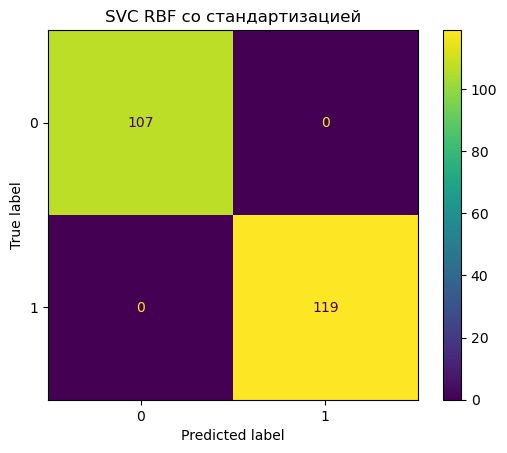

In [5]:
results = []
svm_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", max_iter=200000, cache_size=8000))
])

result = evaluate_model(
    svm_scaled,
    X_train,
    y_train,
    X_test,
    y_test,
    "SVC RBF со стандартизацией"
)

results.append(result)

По результатам обучения базовой модели SVC с RBF-ядром и стандартизацией признаков была получена точность классификации, равная 1,0, то есть модель верно классифицировала все объекты тестовой выборки.

Для класса 0 модель правильно определила все 107 объектов, а для класса 1 – все 119 объектов. Значения precision, recall и f1-score для обоих классов составили 1,00, что говорит об отсутствии ошибок как при определении настоящих банкнот, так и при выявлении фальшивых.

Матрица ошибок подтверждает данный результат: все значения расположены на главной диагонали, а вне диагонали находятся нули. Это означает, что ложноположительные и ложноотрицательные классификации отсутствуют.

SVC linear
Accuracy: 0.977876
Total time: 0.100516
Performance time: 0.100516
Processor time: 0.09375

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       107
           1       0.96      1.00      0.98       119

    accuracy                           0.98       226
   macro avg       0.98      0.98      0.98       226
weighted avg       0.98      0.98      0.98       226

Confusion matrix:
[[102   5]
 [  0 119]]


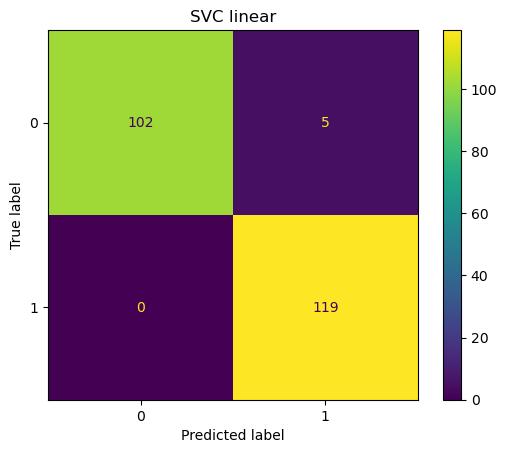

SVC rbf
Accuracy: 1.0
Total time: 0.041012
Performance time: 0.041012
Processor time: 0.046875

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       1.00      1.00      1.00       119

    accuracy                           1.00       226
   macro avg       1.00      1.00      1.00       226
weighted avg       1.00      1.00      1.00       226

Confusion matrix:
[[107   0]
 [  0 119]]


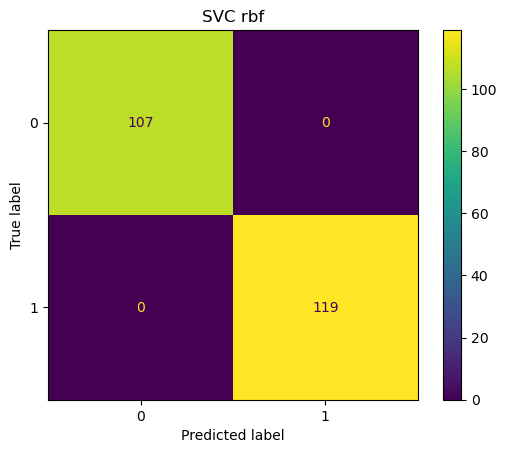

SVC polynomial
Accuracy: 0.99115
Total time: 0.047348
Performance time: 0.047348
Processor time: 0.046875

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       107
           1       0.98      1.00      0.99       119

    accuracy                           0.99       226
   macro avg       0.99      0.99      0.99       226
weighted avg       0.99      0.99      0.99       226

Confusion matrix:
[[105   2]
 [  0 119]]


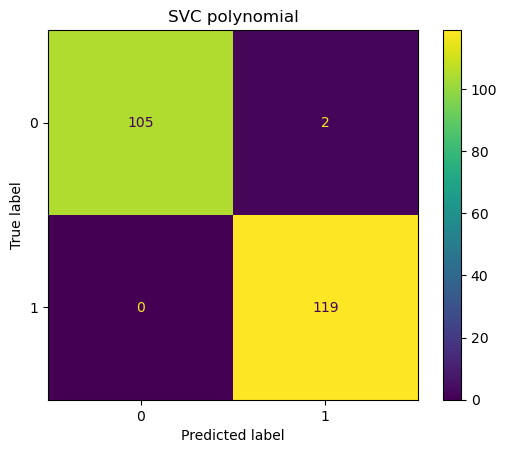

SVC sigmoid
Accuracy: 0.738938
Total time: 0.042466
Performance time: 0.042466
Processor time: 0.046875

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       107
           1       0.77      0.71      0.74       119

    accuracy                           0.74       226
   macro avg       0.74      0.74      0.74       226
weighted avg       0.74      0.74      0.74       226

Confusion matrix:
[[82 25]
 [34 85]]


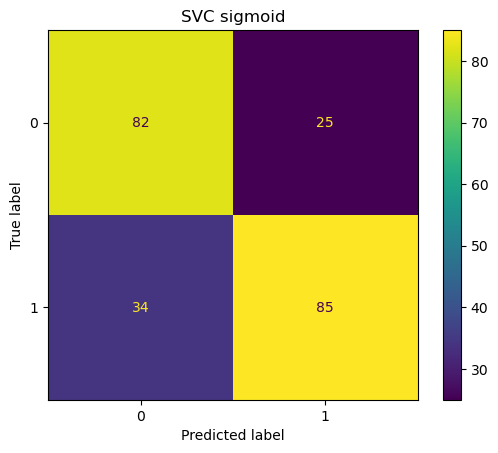

In [6]:
models = {
    "SVC linear": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", max_iter=200000, cache_size=8000))
    ]),
    
    "SVC rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", max_iter=200000, cache_size=8000))
    ]),
    
    "SVC polynomial": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="poly", degree=3, max_iter=200000, cache_size=8000))
    ]),
    
    "SVC sigmoid": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="sigmoid", max_iter=200000, cache_size=8000))
    ])
}

for model_name, model in models.items():
    result = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        model_name
    )
    results.append(result)

In [7]:
results_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False)
results_df

,model,accuracy,total_time,performance_time,processor_time
0,SVC RBF со стандартизацией,1.000000,0.046785,0.046787,0.046875
2,SVC rbf,1.000000,0.041012,0.041012,0.046875
3,SVC polynomial,0.991150,0.047348,0.047348,0.046875
1,SVC linear,0.977876,0.100516,0.100516,0.093750
4,SVC sigmoid,0.738938,0.042466,0.042466,0.046875


На данном этапе были проверены разные базовые настройки SVM.  
Различия между моделями связаны прежде всего с выбором ядра:

- `linear` строит линейную разделяющую границу;
- `rbf` позволяет строить нелинейную границу и часто хорошо работает по умолчанию;
- `poly` использует полиномиальное ядро;
- `sigmoid` применяет сигмоидальное преобразование.

По результатам сравнения базовых моделей SVM наилучшее качество показали модели с RBF-ядром. Модель SVC RBF со стандартизацией и модель SVC rbf достигли точности 1,0, то есть корректно классифицировали все объекты тестовой выборки.

Полиномиальное ядро также показало высокий результат – точность составила 0,991150, однако оно уступило RBF-ядру. Линейная модель дала точность 0,977876, что также является хорошим результатом, но говорит о том, что данные лучше разделяются нелинейной границей. Наименьшее качество показала модель с сигмоидальным ядром – 0,738938, поэтому для данного набора данных оно оказалось наименее подходящим.

Таким образом, для задачи выявления фальшивых банкнот наиболее эффективным оказался метод опорных векторов с RBF-ядром. Высокие результаты объясняются тем, что признаки банкнот хорошо разделяют классы, а нелинейное ядро позволяет построить более гибкую границу классификации.

### Метод опорных векторов на большой и маленькой выборке Adult Income


В данной части лабораторной работы проверяется, как ведут себя модели SVM при обучении на выборках разного размера.

Основной вопрос исследования:

**как меняется качество классификации SVM, если модель обучается не на всей доступной обучающей выборке, а только на малой ее части?**

Для проверки используется набор данных `Adult Income`, содержащий социально-демографические и профессиональные признаки людей. Целевая переменная показывает, относится ли доход человека к категории `>50K` или `<=50K`.

В работе сравниваются два варианта обучения:

1. обучение на малой выборке – 10 % от исходного датасета;
2. обучение на большой выборке – 80 % от исходного датасета.

Для обеих выборок проверяются разные варианты SVM-моделей.

In [8]:
adult = pd.read_csv("adult.csv")

print("Информация о столбцах:")
display(adult.info())

print("\nКоличество пропусков по столбцам:")
display(adult.isna().sum())

print("\nПервые 5 строк:")
display(adult.head())

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


None


Количество пропусков по столбцам:


age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


Первые 5 строк:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Набор данных Adult Income содержит признаки, описывающие социально-демографические и трудовые характеристики людей.  
В отличие от набора Banknote Authentication, где все признаки были числовыми, в данном датасете присутствуют как числовые, так и категориальные признаки.

Поэтому перед обучением SVM требуется выполнить предобработку:

- очистить строковые значения от лишних пробелов;
- заменить неизвестные значения `?` на пропуски;
- удалить строки с пропущенными значениями;
- закодировать категориальные признаки;
- стандартизировать числовые признаки.

In [9]:
# Удаление лишних пробелов в строковых столбцах

for col in adult.select_dtypes(include="object").columns:
    adult[col] = adult[col].astype(str).str.strip()

# Замена '?' на NaN
adult = adult.replace("?", np.nan)

print("Количество пропусков после замены '?':")
display(adult.isna().sum())

# Удаление строк с пропусками
adult = adult.dropna().reset_index(drop=True)

print("\nРазмерность после удаления пропусков:", adult.shape)

Количество пропусков после замены '?':


age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


Размерность после удаления пропусков: (45222, 15)


In [10]:
target_column = "income"

if target_column not in adult.columns:
    raise ValueError(
        f"Столбец '{target_column}' не найден. "
        f"Доступные столбцы: {adult.columns.tolist()}"
    )

print("Целевая переменная:", target_column)

print("\nРаспределение классов:")
display(adult[target_column].value_counts())

print("\nДоля классов:")
display(adult[target_column].value_counts(normalize=True))

X = adult.drop(columns=[target_column])
y = adult[target_column]

Целевая переменная: income

Распределение классов:


income
<=50K    34014
>50K     11208
Name: count, dtype: int64


Доля классов:


income
<=50K    0.752156
>50K     0.247844
Name: proportion, dtype: float64

In [11]:
# Формирование тестовой выборки в 20%

X_pool, X_test, y_pool, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Размер исходного датасета:", X.shape[0])
print("Размер тестовой выборки 20%:", X_test.shape[0])
print("Размер пула для обучения 80%:", X_pool.shape[0])

print("\nРаспределение классов в тестовой выборке:")
display(y_test.value_counts(normalize=True))

Размер исходного датасета: 45222
Размер тестовой выборки 20%: 9045
Размер пула для обучения 80%: 36177

Распределение классов в тестовой выборке:


income
<=50K    0.752128
>50K     0.247872
Name: proportion, dtype: float64

In [12]:
# Большая обучающая выборка – все 80%, оставшиеся после выделения test
X_train_80 = X_pool.copy()
y_train_80 = y_pool.copy()

# Малая обучающая выборка – 10% от всего исходного датасета
# Так как X_pool составляет 80% от исходного датасета,
# нужно взять 12.5% от X_pool, чтобы получить 10% от всего набора:
# 0.125 * 0.80 = 0.10

X_train_10, _, y_train_10, _ = train_test_split(
    X_pool,
    y_pool,
    train_size=0.125,
    random_state=42,
    stratify=y_pool
)

print("Размер малой обучающей выборки 10%:", X_train_10.shape[0])
print("Размер большой обучающей выборки 80%:", X_train_80.shape[0])
print("Размер тестовой выборки 20%:", X_test.shape[0])

Размер малой обучающей выборки 10%: 4522
Размер большой обучающей выборки 80%: 36177
Размер тестовой выборки 20%: 9045


In [13]:
print("Распределение классов в малой обучающей выборке 10%:")
display(y_train_10.value_counts(normalize=True))

print("\nРаспределение классов в большой обучающей выборке 80%:")
display(y_train_80.value_counts(normalize=True))

print("\nРаспределение классов в тестовой выборке 20%:")
display(y_test.value_counts(normalize=True))

Распределение классов в малой обучающей выборке 10%:


income
<=50K    0.752101
>50K     0.247899
Name: proportion, dtype: float64


Распределение классов в большой обучающей выборке 80%:


income
<=50K    0.752163
>50K     0.247837
Name: proportion, dtype: float64


Распределение классов в тестовой выборке 20%:


income
<=50K    0.752128
>50K     0.247872
Name: proportion, dtype: float64

Для корректного сравнения используется одна и та же тестовая выборка размером 20 % от исходного датасета.

Это важно, потому что модели, обученные на 10 % и 80 % данных, должны проверяться на одинаковых объектах.  
Тогда различия в качестве будут связаны именно с размером обучающей выборки и параметрами модели, а не с разным составом тестовых данных.

Малая обучающая выборка составляет 10 % от исходного датасета.  
Большая обучающая выборка составляет 80 % от исходного датасета.

In [14]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Числовые признаки:
['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Категориальные признаки:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [15]:
#Описание моделей SVM
svm_models = {
    "SVC linear": SVC(
        kernel="linear",
        C=1,
        max_iter=100000,
        cache_size=4000
    ),
    
    "SVC rbf": SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        max_iter=100000,
        cache_size=4000
    ),
    
    "SVC poly": SVC(
        kernel="poly",
        degree=3,
        C=1,
        gamma="scale",
        max_iter=100000,
        cache_size=4000
    ),
    
    "SVC sigmoid": SVC(
        kernel="sigmoid",
        C=1,
        gamma="scale",
        max_iter=100000,
        cache_size=4000
    ),
    
    "LinearSVC": LinearSVC(
        C=1,
        max_iter=100000,
        random_state=42
    )
}

print("Количество моделей для сравнения:", len(svm_models))
print(list(svm_models.keys()))

Количество моделей для сравнения: 5
['SVC linear', 'SVC rbf', 'SVC poly', 'SVC sigmoid', 'LinearSVC']


In [16]:
def train_and_evaluate_svm(model_name, model, X_train, y_train, X_test, y_test, sample_name):
    """
    Обучает SVM-модель на заданной выборке и оценивает качество на общей тестовой выборке.
    """
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    start_time = time.time()
    start_perf = time.perf_counter()
    start_proc = time.process_time()
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    total_time = time.time() - start_time
    performance_time = time.perf_counter() - start_perf
    processor_time = time.process_time() - start_proc
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    return {
        "sample": sample_name,
        "model": model_name,
        "train_size": X_train.shape[0],
        "test_size": X_test.shape[0],
        "accuracy": accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "total_time": total_time,
        "performance_time": performance_time,
        "processor_time": processor_time,
        "pipeline": pipeline,
        "y_pred": y_pred
    }

#### Обучение на 10%


In [17]:
results_10 = []

for model_name, model in svm_models.items():
    print(f"Обучение модели {model_name} на выборке 10%...")
    
    result = train_and_evaluate_svm(
        model_name=model_name,
        model=model,
        X_train=X_train_10,
        y_train=y_train_10,
        X_test=X_test,
        y_test=y_test,
        sample_name="train 10%"
    )
    
    results_10.append(result)

print("Готово.")

Обучение модели SVC linear на выборке 10%...
Обучение модели SVC rbf на выборке 10%...
Обучение модели SVC poly на выборке 10%...
Обучение модели SVC sigmoid на выборке 10%...
Обучение модели LinearSVC на выборке 10%...
Готово.


In [18]:
results_10_df = pd.DataFrame(results_10).drop(columns=["pipeline", "y_pred"])
results_10_df = results_10_df.sort_values(by="accuracy", ascending=False)

display(results_10_df)

,sample,model,train_size,test_size,accuracy,precision_weighted,recall_weighted,f1_weighted,total_time,performance_time,processor_time
1,train 10%,SVC rbf,4522,9045,0.846656,0.840015,0.846656,0.840731,3.100858,3.100858,3.031250
0,train 10%,SVC linear,4522,9045,0.845218,0.838707,0.845218,0.839787,4.910362,4.910365,4.781250
4,train 10%,LinearSVC,4522,9045,0.844666,0.838468,0.844666,0.839812,0.129717,0.129717,0.125000
2,train 10%,SVC poly,4522,9045,0.841791,0.834224,0.841791,0.834240,3.917953,3.917954,3.843750
3,train 10%,SVC sigmoid,4522,9045,0.770370,0.766979,0.770370,0.768571,2.242922,2.242922,2.109375


In [19]:
results_80 = []

for model_name, model in svm_models.items():
    print(f"Обучение модели {model_name} на выборке 80%...")
    
    result = train_and_evaluate_svm(
        model_name=model_name,
        model=model,
        X_train=X_train_80,
        y_train=y_train_80,
        X_test=X_test,
        y_test=y_test,
        sample_name="train 80%"
    )
    
    results_80.append(result)

print("Готово.")

Обучение модели SVC linear на выборке 80%...
Обучение модели SVC rbf на выборке 80%...
Обучение модели SVC poly на выборке 80%...
Обучение модели SVC sigmoid на выборке 80%...
Обучение модели LinearSVC на выборке 80%...
Готово.


In [20]:
results_80_df = pd.DataFrame(results_80).drop(columns=["pipeline", "y_pred"])
results_80_df = results_80_df.sort_values(by="accuracy", ascending=False)

display(results_80_df)

,sample,model,train_size,test_size,accuracy,precision_weighted,recall_weighted,f1_weighted,total_time,performance_time,processor_time
1,train 80%,SVC rbf,36177,9045,0.850857,0.844493,0.850857,0.844724,102.888489,102.888489,100.609375
2,train 80%,SVC poly,36177,9045,0.846324,0.839408,0.846324,0.839633,154.919806,154.919807,153.187500
4,train 80%,LinearSVC,36177,9045,0.845661,0.838884,0.845661,0.839586,0.870762,0.870762,0.843750
0,train 80%,SVC linear,36177,9045,0.843892,0.836683,0.843892,0.836962,207.953506,207.953507,205.265625
3,train 80%,SVC sigmoid,36177,9045,0.772360,0.771112,0.772360,0.771722,80.890990,80.890995,79.609375


In [21]:
all_results = results_10 + results_80

all_results_df = pd.DataFrame(all_results).drop(columns=["pipeline", "y_pred"])

all_results_df = all_results_df.sort_values(
    by=["model", "sample"]
).reset_index(drop=True)

display(all_results_df)

,sample,model,train_size,test_size,accuracy,precision_weighted,recall_weighted,f1_weighted,total_time,performance_time,processor_time
0,train 10%,LinearSVC,4522,9045,0.844666,0.838468,0.844666,0.839812,0.129717,0.129717,0.125000
1,train 80%,LinearSVC,36177,9045,0.845661,0.838884,0.845661,0.839586,0.870762,0.870762,0.843750
2,train 10%,SVC linear,4522,9045,0.845218,0.838707,0.845218,0.839787,4.910362,4.910365,4.781250
3,train 80%,SVC linear,36177,9045,0.843892,0.836683,0.843892,0.836962,207.953506,207.953507,205.265625
4,train 10%,SVC poly,4522,9045,0.841791,0.834224,0.841791,0.834240,3.917953,3.917954,3.843750
5,train 80%,SVC poly,36177,9045,0.846324,0.839408,0.846324,0.839633,154.919806,154.919807,153.187500
6,train 10%,SVC rbf,4522,9045,0.846656,0.840015,0.846656,0.840731,3.100858,3.100858,3.031250
7,train 80%,SVC rbf,36177,9045,0.850857,0.844493,0.850857,0.844724,102.888489,102.888489,100.609375
8,train 10%,SVC sigmoid,4522,9045,0.770370,0.766979,0.770370,0.768571,2.242922,2.242922,2.109375
9,train 80%,SVC sigmoid,36177,9045,0.772360,0.771112,0.772360,0.771722,80.890990,80.890995,79.609375


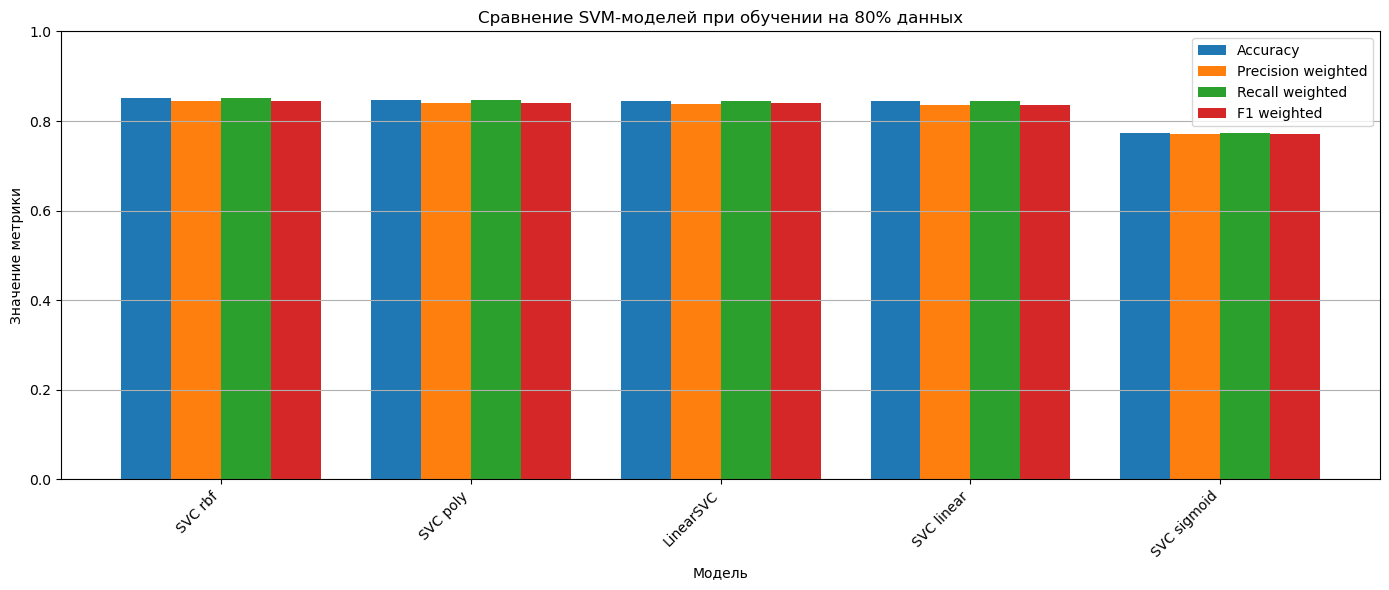

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Берем только результаты моделей, обученных на 80% данных
results_80_only = all_results_df[
    all_results_df["sample"] == "train 80%"
].copy()

# Сортируем по accuracy
results_80_only = results_80_only.sort_values(
    by="accuracy",
    ascending=False
)

# Названия моделей
models = results_80_only["model"]

# Метрики для сравнения
accuracy = results_80_only["accuracy"]
precision = results_80_only["precision_weighted"]
recall = results_80_only["recall_weighted"]
f1 = results_80_only["f1_weighted"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(14, 6))

plt.bar(x - 1.5 * width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5 * width, precision, width, label="Precision weighted")
plt.bar(x + 0.5 * width, recall, width, label="Recall weighted")
plt.bar(x + 1.5 * width, f1, width, label="F1 weighted")

plt.title("Сравнение SVM-моделей при обучении на 80% данных")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.xticks(x, models, rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Лучшая модель на малой выборке 10%
best_10 = all_results_df[
    all_results_df["sample"] == "train 10%"
].sort_values(
    by="accuracy",
    ascending=False
).iloc[0]

# Лучшая модель на большой выборке 80%
best_80 = all_results_df[
    all_results_df["sample"] == "train 80%"
].sort_values(
    by="accuracy",
    ascending=False
).iloc[0]

print("Лучшая модель на 10% данных:")
print(best_10[["model", "accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]])

print("\nЛучшая модель на 80% данных:")
print(best_80[["model", "accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]])

Лучшая модель на 10% данных:
model                  SVC rbf
accuracy              0.846656
precision_weighted    0.840015
recall_weighted       0.846656
f1_weighted           0.840731
Name: 6, dtype: object

Лучшая модель на 80% данных:
model                  SVC rbf
accuracy              0.850857
precision_weighted    0.844493
recall_weighted       0.850857
f1_weighted           0.844724
Name: 7, dtype: object


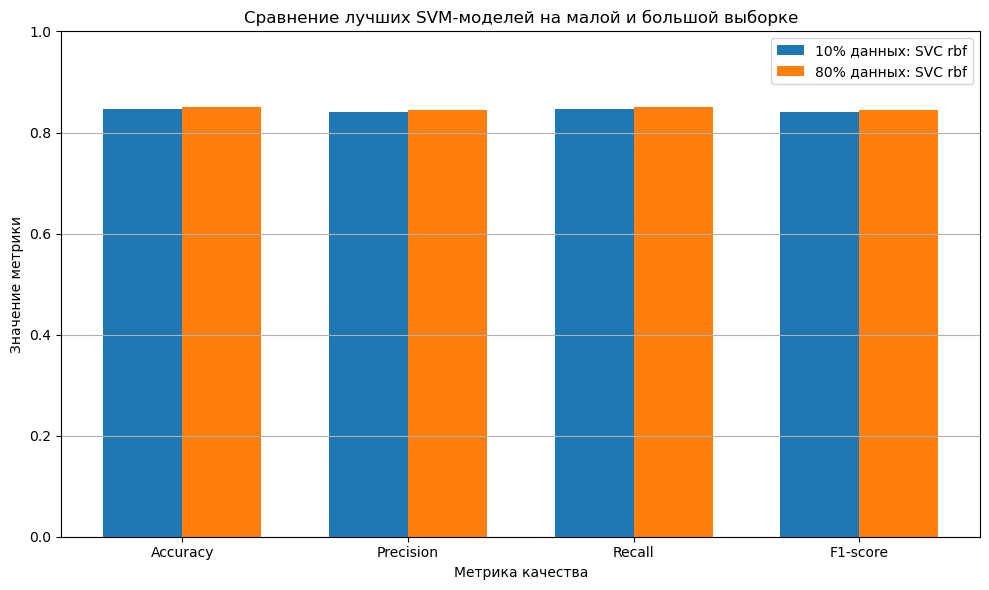

In [26]:
labels = ["Accuracy", "Precision", "Recall", "F1-score"]

best_10_values = [
    best_10["accuracy"],
    best_10["precision_weighted"],
    best_10["recall_weighted"],
    best_10["f1_weighted"]
]

best_80_values = [
    best_80["accuracy"],
    best_80["precision_weighted"],
    best_80["recall_weighted"],
    best_80["f1_weighted"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    best_10_values,
    width,
    label=f"10% данных: {best_10['model']}"
)

plt.bar(
    x + width / 2,
    best_80_values,
    width,
    label=f"80% данных: {best_80['model']}"
)

plt.title("Сравнение лучших SVM-моделей на малой и большой выборке")
plt.xlabel("Метрика качества")
plt.ylabel("Значение метрики")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()

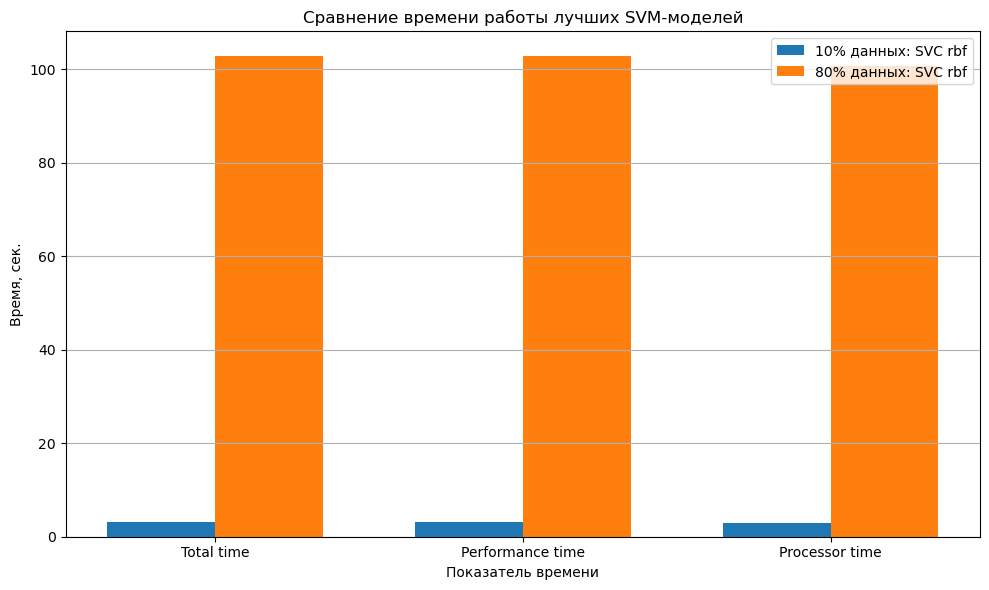

In [27]:
time_labels = ["Total time", "Performance time", "Processor time"]

best_10_time = [
    best_10["total_time"],
    best_10["performance_time"],
    best_10["processor_time"]
]

best_80_time = [
    best_80["total_time"],
    best_80["performance_time"],
    best_80["processor_time"]
]

x = np.arange(len(time_labels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    best_10_time,
    width,
    label=f"10% данных: {best_10['model']}"
)

plt.bar(
    x + width / 2,
    best_80_time,
    width,
    label=f"80% данных: {best_80['model']}"
)

plt.title("Сравнение времени работы лучших SVM-моделей")
plt.xlabel("Показатель времени")
plt.ylabel("Время, сек.")
plt.xticks(x, time_labels)
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
print("Вывод:")
print(
    f"При обучении на малой выборке 10% лучшей оказалась модель "
    f"{best_10['model']} с accuracy = {best_10['accuracy']:.4f} "
    f"и F1-score = {best_10['f1_weighted']:.4f}."
)

print(
    f"При обучении на большой выборке 80% лучшей оказалась модель "
    f"{best_80['model']} с accuracy = {best_80['accuracy']:.4f} "
    f"и F1-score = {best_80['f1_weighted']:.4f}."
)

print(
    f"Разница по accuracy между лучшими моделями составила "
    f"{best_80['accuracy'] - best_10['accuracy']:.4f}."
)

Вывод:
При обучении на малой выборке 10% лучшей оказалась модель SVC rbf с accuracy = 0.8467 и F1-score = 0.8407.
При обучении на большой выборке 80% лучшей оказалась модель SVC rbf с accuracy = 0.8509 и F1-score = 0.8447.
Разница по accuracy между лучшими моделями составила 0.0042.
